Customer Segmentation Project

Mall Customers dataset
we will implement K means clustering to check the spending patterns of our customers
segment the customer spending behaviour
Task:

1. Data ingestion/acquisition
2. Data EDA
3. Preprocessing, if needed
4. Train a model
5. Cluster the users

Optional 6. Tag each cluter with a name and save that column in dataframe

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

df = pd.read_csv(url)
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [8]:
##Data Cleaning bcs have non numerical column and remove the id bcs its sequential
#use one hot encoding

df_cleaned = df.drop(columns=['CustomerID'])
df_encoded = pd.get_dummies(df_cleaned, columns=['Gender'], dtype=int)
df_encoded

#scale
from scipy.stats import zscore

df_scaled = df_encoded.apply(zscore)
df_scaled


,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male
0,-1.424569,-1.738999,-0.434801,-1.128152,1.128152
1,-1.281035,-1.738999,1.195704,-1.128152,1.128152
2,-1.352802,-1.700830,-1.715913,0.886405,-0.886405
3,-1.137502,-1.700830,1.040418,0.886405,-0.886405
4,-0.563369,-1.662660,-0.395980,0.886405,-0.886405
...,...,...,...,...,...
195,-0.276302,2.268791,1.118061,0.886405,-0.886405
196,0.441365,2.497807,-0.861839,0.886405,-0.886405
197,-0.491602,2.497807,0.923953,-1.128152,1.128152
198,-0.491602,2.917671,-1.250054,-1.128152,1.128152


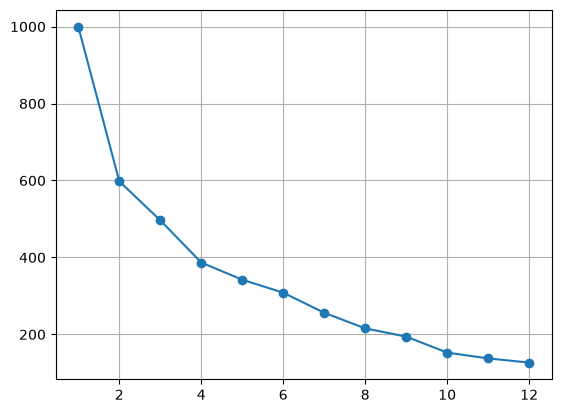

In [9]:
# Elbow Method

errors = []

for k in range(1, 13):
    kmeans = KMeans(n_clusters = k, random_state= 42)
    kmeans.fit(df_scaled)
    errors.append(kmeans.inertia_)

plt.plot(range(1,13), errors, marker = 'o')
plt.grid()
plt.show()


In [10]:
model_kmeans = KMeans(
    n_clusters = 5, # based on elbow
    init = 'random',
    random_state = 42
)

model_kmeans

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


KMeans(init='random', n_clusters=5, random_state=42)
In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.


In [11]:
df_scaled['KClustering'] = model_kmeans.fit_predict(df_scaled)
df_scaled


,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,KClustering
0,-1.424569,-1.738999,-0.434801,-1.128152,1.128152,1
1,-1.281035,-1.738999,1.195704,-1.128152,1.128152,1
2,-1.352802,-1.700830,-1.715913,0.886405,-0.886405,4
3,-1.137502,-1.700830,1.040418,0.886405,-0.886405,4
4,-0.563369,-1.662660,-0.395980,0.886405,-0.886405,4
...,...,...,...,...,...,...
195,-0.276302,2.268791,1.118061,0.886405,-0.886405,0
196,0.441365,2.497807,-0.861839,0.886405,-0.886405,3
197,-0.491602,2.497807,0.923953,-1.128152,1.128152,1
198,-0.491602,2.917671,-1.250054,-1.128152,1.128152,2


In [12]:

df_scaled['Annual Income (k$)'].min()

np.float64(-1.7389991930659485)

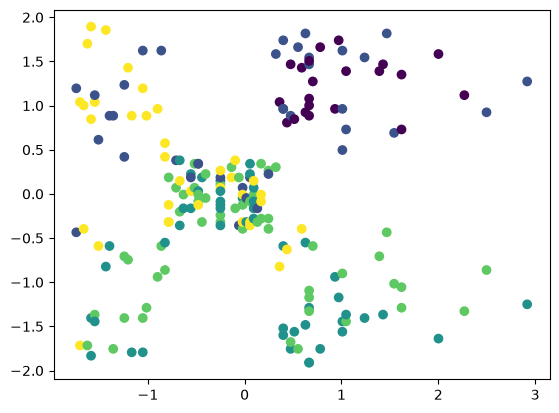

In [13]:
plt.scatter(df_scaled['Annual Income (k$)'],df_scaled['Spending Score (1-100)'], c = df_scaled['KClustering'])
plt.show()

In [14]:
cluster_names = {
    0: "Normal",
    1: "High Income, High Spending",
    2: "Low Income, High Spending",
    3: "High Income, Low Spending",
    4: "Low Income, Low Spending"
}

df_scaled["Customer Type"] = df_scaled["KClustering"].map(cluster_names)
df_scaled.sample(7)


,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,KClustering,Customer Type
65,-1.496335,-0.479408,0.341630,-1.128152,1.128152,1,"High Income, High Spending"
36,0.226065,-1.013780,-1.288876,0.886405,-0.886405,3,"High Income, Low Spending"
120,-0.850435,0.245811,0.225165,-1.128152,1.128152,1,"High Income, High Spending"
103,-0.922202,0.054964,0.186343,-1.128152,1.128152,1,"High Income, High Spending"
124,-1.137502,0.360319,-0.823017,0.886405,-0.886405,4,"Low Income, Low Spending"
27,-0.276302,-1.242797,0.419273,-1.128152,1.128152,1,"High Income, High Spending"
163,-0.563369,0.780183,1.661563,0.886405,-0.886405,0,Normal
